**PART A PREPROCCESSING**

In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
TRAIN_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
TEST_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

In [16]:
!pip install kagglehub


In [17]:
import kagglehub

asl_path = kagglehub.dataset_download('grassknoted/asl-alphabet')
print("ASL dataset downloaded to:", asl_path)


Using Colab cache for faster access to the 'asl-alphabet' dataset.
ASL dataset downloaded to: /kaggle/input/asl-alphabet


In [18]:
TRAIN_DIR = os.path.join(asl_path, "asl_alphabet_train", "asl_alphabet_train")
TEST_DIR  = os.path.join(asl_path, "asl_alphabet_test", "asl_alphabet_test")


In [19]:
print(os.listdir(TRAIN_DIR)[:5])


['N', 'R', 'space', 'B', 'I']


In [20]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
grassknoted_asl_alphabet_path = kagglehub.dataset_download('grassknoted/asl-alphabet')

print('Data source import complete.')


Using Colab cache for faster access to the 'asl-alphabet' dataset.
Data source import complete.


In [21]:
print(f"Training folder exists: {os.path.exists(TRAIN_DIR)}")
print(f"Test folder exists: {os.path.exists(TEST_DIR)}")


Training folder exists: True
Test folder exists: True


In [22]:
classes = sorted(os.listdir(TRAIN_DIR))
print(f"\n CLASS INFORMATION:")
print(f"Number of classes: {len(classes)}")
print("All classes:", classes)


 CLASS INFORMATION:
Number of classes: 29
All classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [23]:
class_counts = {}
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        num_images = len(image_files)
        class_counts[cls] = num_images
        print(f"  {cls}: {num_images} images")

  A: 3000 images
  B: 3000 images
  C: 3000 images
  D: 3000 images
  E: 3000 images
  F: 3000 images
  G: 3000 images
  H: 3000 images
  I: 3000 images
  J: 3000 images
  K: 3000 images
  L: 3000 images
  M: 3000 images
  N: 3000 images
  O: 3000 images
  P: 3000 images
  Q: 3000 images
  R: 3000 images
  S: 3000 images
  T: 3000 images
  U: 3000 images
  V: 3000 images
  W: 3000 images
  X: 3000 images
  Y: 3000 images
  Z: 3000 images
  del: 3000 images
  nothing: 3000 images
  space: 3000 images


In [24]:
total_images = sum(class_counts.values())
print(f"Total training images: {total_images:,}")
print(f"Average per class: {total_images/len(classes):.0f} images")

Total training images: 87,000
Average per class: 3000 images


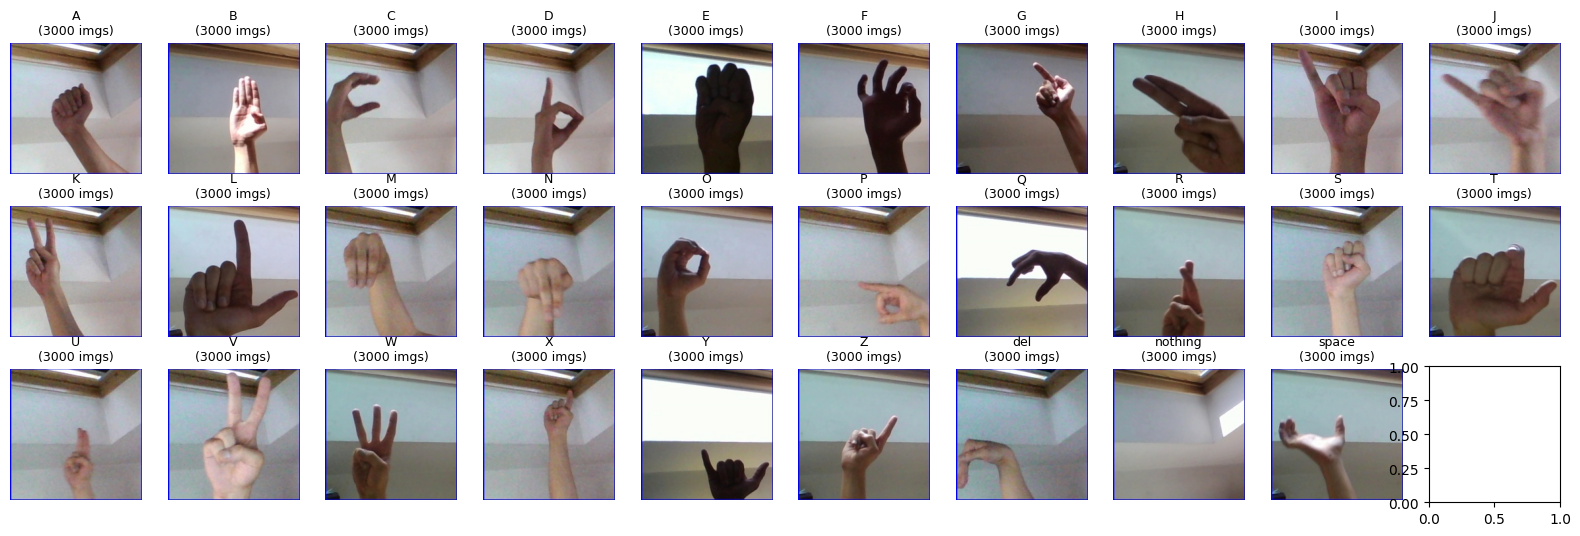

In [25]:
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i, cls in enumerate(classes[:30]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files:
            img_path = os.path.join(cls_path, image_files[0])
            img = mpimg.imread(img_path)

            row = i // 10
            col = i % 10
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"{cls}\n({class_counts[cls]} imgs)", fontsize=9)
            axes[row, col].axis('off')

In [26]:
sample_class = classes[0]
sample_path = os.path.join(TRAIN_DIR, sample_class)
sample_image = [f for f in os.listdir(sample_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
img = mpimg.imread(os.path.join(sample_path, sample_image))

print(f"Image shape: {img.shape} (Height, Width, Channels)")
print(f"Image dtype: {img.dtype}")
print(f"Pixel value range: {img.min()} to {img.max()}")

Image shape: (200, 200, 3) (Height, Width, Channels)
Image dtype: uint8
Pixel value range: 0 to 255


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
TRAIN_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
TEST_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.2  # 20% for validation

In [28]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    validation_split=VALIDATION_SPLIT,

    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest',

    horizontal_flip=False,

)

In [29]:
train_generator = train_datagen.flow_from_directory(
TRAIN_DIR,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='training',
seed=SEED,
shuffle=True
)

Found 69600 images belonging to 29 classes.


In [30]:
validation_generator = train_datagen.flow_from_directory(
TRAIN_DIR,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='validation',
seed=SEED,
shuffle=False
)

Found 17400 images belonging to 29 classes.


In [31]:
print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {validation_generator.samples:,}")
print(f"Total samples: {train_generator.samples + validation_generator.samples:,}")
print(f"Number of classes: {len(train_generator.class_indices)}")
print(f"Classes: {list(train_generator.class_indices.keys())}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}")
print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(validation_generator)}")

Training samples: 69,600
Validation samples: 17,400
Total samples: 87,000
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Batch size: 32
Image size: (224, 224)
Training batches: 2175
Validation batches: 544


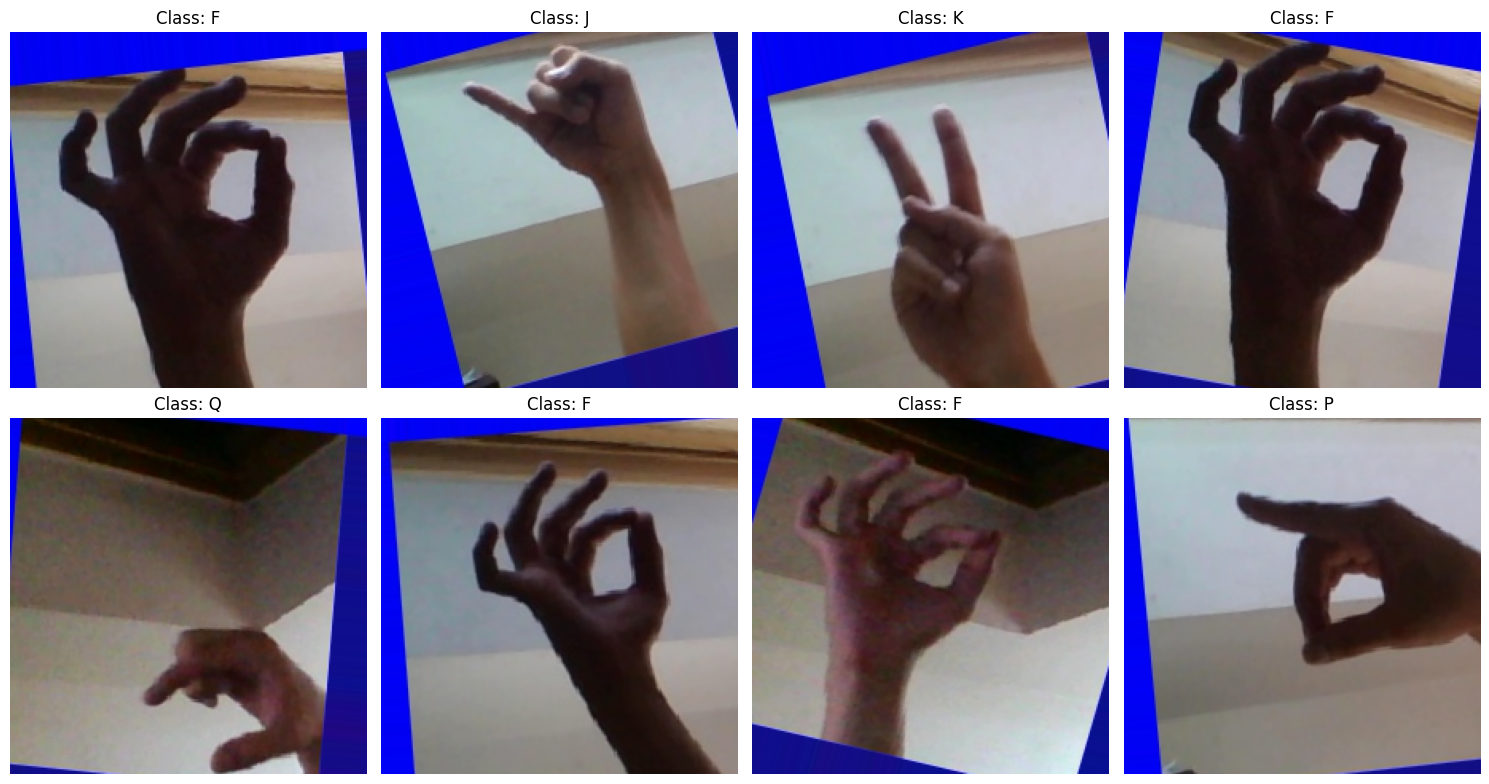

In [32]:
images, labels = next(train_generator)

plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])

    class_idx = labels[i].argmax()
    class_name = list(train_generator.class_indices.keys())[class_idx]

    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [33]:
print(f"Pixel range before: 0-255")
print(f"Pixel range after: {images.min():.3f} to {images.max():.3f}")
print(f"Image shape in batch: {images[0].shape}")

Pixel range before: 0-255
Pixel range after: 0.000 to 1.000
Image shape in batch: (224, 224, 3)


In [34]:
test_base = "/kaggle/input/asl-alphabet"

if os.path.exists(TEST_DIR):
    print(f"Test directory exists: {TEST_DIR}")

    # List what's inside
    print(f"Contents of test directory:")
    for item in os.listdir(TEST_DIR):
        item_path = os.path.join(TEST_DIR, item)
        if os.path.isdir(item_path):
            print(f"{item}/ (directory)")
        else:
            print(f"{item} (file)")

Test directory exists: /kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test
Contents of test directory:
A_test.jpg (file)
E_test.jpg (file)
L_test.jpg (file)
N_test.jpg (file)
S_test.jpg (file)
D_test.jpg (file)
G_test.jpg (file)
I_test.jpg (file)
W_test.jpg (file)
M_test.jpg (file)
nothing_test.jpg (file)
X_test.jpg (file)
H_test.jpg (file)
Q_test.jpg (file)
C_test.jpg (file)
T_test.jpg (file)
P_test.jpg (file)
V_test.jpg (file)
Y_test.jpg (file)
U_test.jpg (file)
space_test.jpg (file)
O_test.jpg (file)
B_test.jpg (file)
R_test.jpg (file)
F_test.jpg (file)
Z_test.jpg (file)
J_test.jpg (file)
K_test.jpg (file)


In [35]:
test_base_path = "/kaggle/input/asl-alphabet/asl_alphabet_test"
if os.path.exists(test_base_path):
    for root, dirs, files in os.walk(test_base_path):
        level = root.replace(test_base_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)

        for file in files[:5]:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

    test_count = 0
    for root, dirs, files in os.walk(test_base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                test_count += 1

asl_alphabet_test/
  asl_alphabet_test/
    A_test.jpg
    E_test.jpg
    L_test.jpg
    N_test.jpg
    S_test.jpg
    ... and 23 more files


In [36]:
IMG_SIZE = (240, 240)   # EfficientNetB1 input size
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = len(os.listdir(TRAIN_DIR))


In [37]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [38]:
sorted(os.listdir(TRAIN_DIR))


['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'del',
 'nothing',
 'space']

In [39]:
CLASSES = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
CLASSES.append("space")

print(CLASSES)


['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'space']


In [40]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=CLASSES,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=CLASSES,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 64800 images belonging to 27 classes.
Found 16200 images belonging to 27 classes.


In [41]:
print(len(train_generator.class_indices))
print(train_generator.class_indices)


27
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'space': 26}


In [42]:
NUM_CLASSES = train_generator.num_classes


In [43]:
base_model = tf.keras.applications.EfficientNetB1(
    weights="imagenet",
    include_top=False,
    input_shape=(240, 240, 3)
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)


27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [45]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 240, 240,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 240, 240,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 240, 240,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,915,234 (26.38 MB)

 Trainable params: 337,435 (1.29 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

In [46]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 1232s 587ms/step - accuracy: 0.4119 - loss: 2.1734 - val_accuracy: 0.8338 - val_loss: 0.5748
Epoch 2/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 943s 466ms/step - accuracy: 0.8185 - loss: 0.5809 - val_accuracy: 0.8731 - val_loss: 0.4258
Epoch 3/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 948s 468ms/step - accuracy: 0.8841 - loss: 0.3722 - val_accuracy: 0.8799 - val_loss: 0.3917
Epoch 4/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 914s 451ms/step - accuracy: 0.9055 - loss: 0.2951 - val_accuracy: 0.8896 - val_loss: 0.3594
Epoch 5/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 907s 448ms/step - accuracy: 0.9215 - loss: 0.2450 - val_accuracy: 0.8881 - val_loss: 0.3457


In [47]:

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False


In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [49]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 992s 472ms/step - accuracy: 0.9118 - loss: 0.2625 - val_accuracy: 0.8947 - val_loss: 0.3499
Epoch 2/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 984s 486ms/step - accuracy: 0.9457 - loss: 0.1670 - val_accuracy: 0.9023 - val_loss: 0.3239
Epoch 3/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 968s 478ms/step - accuracy: 0.9569 - loss: 0.1347 - val_accuracy: 0.9065 - val_loss: 0.3121
Epoch 4/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 965s 476ms/step - accuracy: 0.9639 - loss: 0.1091 - val_accuracy: 0.9170 - val_loss: 0.2753
Epoch 5/5
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 953s 470ms/step - accuracy: 0.9692 - loss: 0.0969 - val_accuracy: 0.9172 - val_loss: 0.2768


In [50]:
print("Last validation accuracy:",
      history_finetune.history["val_accuracy"][-1])


Last validation accuracy: 0.9172222018241882


In [51]:
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
val_loss, val_acc = model.evaluate(val_generator, verbose=0)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy  : {val_acc:.4f}")


Train Accuracy: 0.9961
Val Accuracy  : 0.9172


In [52]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


val_generator.reset()

# Predictions
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_generator.classes

class_names = list(val_generator.class_indices.keys())


507/507 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step


In [53]:
cm = confusion_matrix(y_true, y_pred)


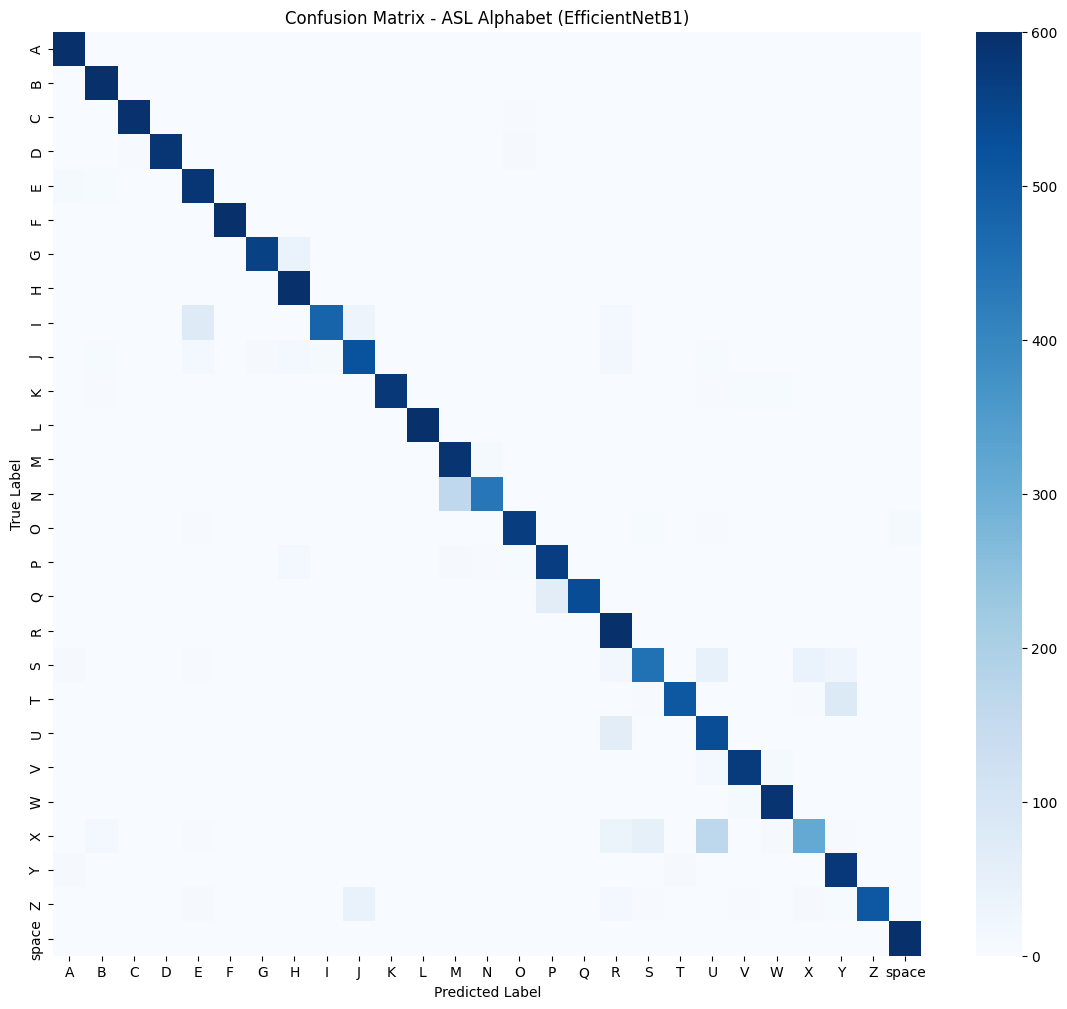

In [54]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ASL Alphabet (EfficientNetB1)")
plt.show()


In [55]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

           A       0.96      1.00      0.98       600
           B       0.95      1.00      0.98       600
           C       0.99      0.99      0.99       600
           D       1.00      0.98      0.99       600
           E       0.84      0.97      0.90       600
           F       1.00      1.00      1.00       600
           G       0.98      0.94      0.96       600
           H       0.90      1.00      0.95       600
           I       0.98      0.80      0.88       600
           J       0.87      0.87      0.87       600
           K       1.00      0.97      0.98       600
           L       1.00      1.00      1.00       600
           M       0.77      0.98      0.87       600
           N       0.96      0.73      0.83       600
           O       0.96      0.95      0.96       600
           P       0.90      0.94      0.92       600
           Q       1.00      0.89      0.94       600
           R       0.78    

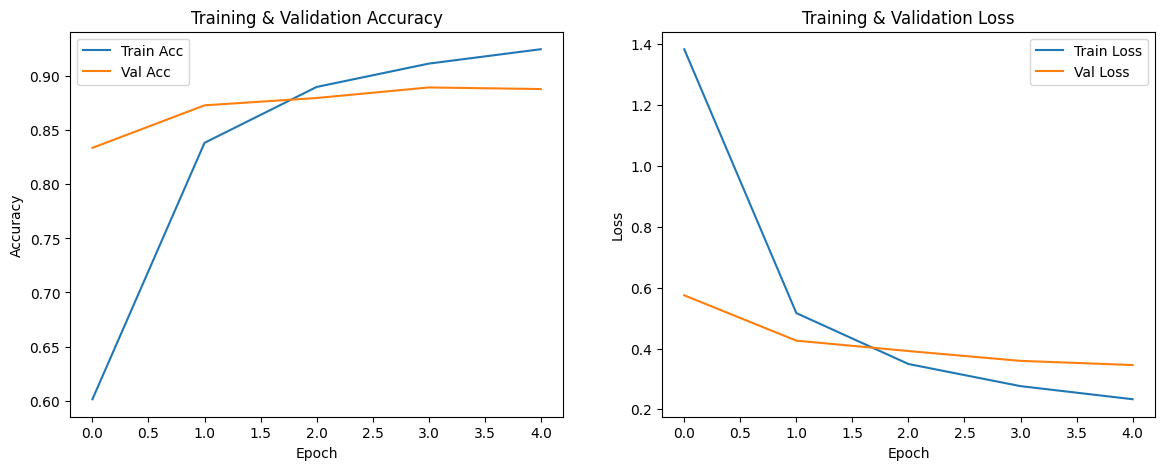

In [56]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


In [57]:
model.save("asl_efficientnet_b1.h5")
